## Model Comparison

Using a fixed feature set from prior L1 → L2 selection, we now evaluate different models.

### Approach
- Freeze features
- Train multiple models (logistic, tree-based)
- Use time-series split with a rolling training (to somewhat account for regime shifts)
- Compare AUC and stability

### Goal
Assess how well different models extract signal from the same features.

In [1]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [2]:
target = "mid_price_moves"

In [3]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet")

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

In [4]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset = final_dataset.dropna().reset_index(drop=True)

final_dataset[target].value_counts()

mid_price_moves
0    25213
1    18786
Name: count, dtype: int64

# Features

In [5]:
features = [
    # Vol
    "realized_vol_20_log1p",
    "realized_vol_5_log1p",

    # trade intensity
    "trade_count_log1p",
    "trade_count_change",

    # trade size
    "std_trade_size_log1p",
    "max_trade_size_log1p",
    "avg_trade_size_log1p",

    # liquidity
    "total_bid_volume_10_log1p",
    "total_book_volume_log1p",

    # volume_pressure
    "max_bid_ask_vol_ratio_log1p",

    # spread
    "rel_spread_log1p",

    # imbalance
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_3",

    # depth shape
    "lob_depth_ratio_4",
    "lob_depth_ratio_2",

    # trade_flow
    "sell_volume_log1p",
]
target = "mid_price_moves"

# Models

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [7]:
LINEAR_MODELS = {
    "logreg_l2": LogisticRegression(l1_ratio=0, C=1.0, solver="lbfgs", max_iter=5000),
    "logreg_l2_strong": LogisticRegression(l1_ratio=0, C=0.1, solver="lbfgs", max_iter=5000),
    "logreg_l1": LogisticRegression(l1_ratio=1.0, C=0.1, solver="liblinear", max_iter=5000),
    "logreg_en": LogisticRegression(l1_ratio=0.5, C=0.1, solver="saga", max_iter=5000),
}

TREE_MODELS = {
    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=50,
        n_jobs=4,
        random_state=42,
        max_features=0.2
    ),

    "xgb": XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss"
)
}

# Previously using walk-forward training, but this does not adapt well to regime changes. Moving to a rolling training setup instead.

In [8]:
splits = 10
size_data = len(final_dataset)

tscv = TimeSeriesSplit(n_splits=splits, gap=50, max_train_size=int(size_data/splits))

In [9]:
X = final_dataset[features]
y = final_dataset[target]

# Logsitc reg

In [10]:
import copy

def train_logistic(X, y, model, tscv, clip_quantiles=(0.01, 0.99)):
    n = len(X)
    fold_oof = []
    fold_aucs = []
    coefs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        oof_preds = np.full(n, np.nan)

        model_fold = model

        X_train = X.iloc[train_idx].copy()
        X_test  = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        lower = X_train.quantile(clip_quantiles[0])
        upper = X_train.quantile(clip_quantiles[1])

        X_train = X_train.clip(lower, upper, axis=1)
        X_test  = X_test.clip(lower, upper, axis=1)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        model_fold.fit(X_train, y_train)
        preds = model.predict_proba(X_test)[:, 1]

        oof_preds[test_idx] = preds

        auc = roc_auc_score(y_test, preds)
        fold_aucs.append(auc)
        fold_oof.append(oof_preds)
        coefs.append(model_fold.coef_[0])

    results = {
        "fold_oof": fold_oof,
        "fold_aucs": fold_aucs,
        "mean_auc": np.mean(fold_aucs),
        "std_auc": np.std(fold_aucs),
        "min_auc": np.min(fold_aucs),
        "coefs": np.array(coefs)
    }

    return results

In [11]:
linear_results = {}

for name, model in LINEAR_MODELS.items():

    res = train_logistic(
        X=X,
        y=y,
        model=model,
        tscv=tscv,
    )

    linear_results[name] = res

In [12]:
import pandas as pd

df_linear = pd.DataFrame({
    k: {
        "mean_auc": v["mean_auc"],
        "std_auc": v["std_auc"],
        "min_auc": v["min_auc"],
        "ir": v["mean_auc"] / v["std_auc"]
    }
    for k, v in linear_results.items()
}).T

df_linear.sort_values("ir", ascending=False)

,mean_auc,std_auc,min_auc,ir
logreg_l2,0.713307,0.049031,0.649917,14.548050
logreg_l1,0.712113,0.049061,0.649526,14.514707
logreg_en,0.712534,0.049628,0.648890,14.357433
logreg_l2_strong,0.713214,0.049876,0.649110,14.299655


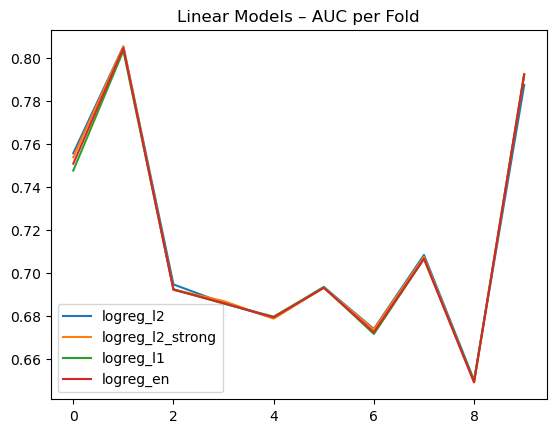

In [13]:
#%%script false

import matplotlib.pyplot as plt

for k, v in linear_results.items():
    plt.plot(v["fold_aucs"], label=k)

plt.legend()
plt.title("Linear Models – AUC per Fold")
plt.show()

# Tree based

In [14]:
def train_tree(X, y, model, tscv, clip_quantiles=(0.01, 0.99)):
    n = len(X)
    fold_oof = []
    fold_aucs = []
    coefs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        oof_preds = np.full(n, np.nan)

        model_fold = model

        # --- split ---
        X_train = X.iloc[train_idx].copy()
        X_test  = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        # --- CLIP ---
        lower = X_train.quantile(clip_quantiles[0])
        upper = X_train.quantile(clip_quantiles[1])

        X_train = X_train.clip(lower, upper, axis=1)
        X_test  = X_test.clip(lower, upper, axis=1)

        model_fold.fit(X_train, y_train)

        preds = model_fold.predict_proba(X_test)[:, 1]

        oof_preds[test_idx] = preds

        auc = roc_auc_score(y_test, preds)
        fold_aucs.append(auc)
        fold_oof.append(oof_preds)
        coefs.append(model_fold.feature_importances_)

    results = {
        "fold_oof": fold_oof,
        "fold_aucs": fold_aucs,
        "mean_auc": np.mean(fold_aucs),
        "std_auc": np.std(fold_aucs),
        "min_auc": np.min(fold_aucs),
        "coefs": np.array(coefs)
    }

    return results

In [15]:
tree_results = {}

for name, model in TREE_MODELS.items():

    res = train_tree(
        X=X,
        y=y,
        model=model,
        tscv=tscv,
    )

    tree_results[name] = res

In [16]:
all_results = {
    **linear_results,
    **tree_results
}

In [17]:
all_results["xgb"].keys()

dict_keys(['fold_oof', 'fold_aucs', 'mean_auc', 'std_auc', 'min_auc', 'coefs'])

In [18]:
import pandas as pd

df_linear = pd.DataFrame({
    k: {
        "mean_auc": v["mean_auc"],
        "std_auc": v["std_auc"],
        "min_auc": v["min_auc"],
        "ir": v["mean_auc"] / v["std_auc"]
    }
    for k, v in all_results.items()
}).T

df_linear.sort_values("ir", ascending=False)

,mean_auc,std_auc,min_auc,ir
logreg_l2,0.713307,0.049031,0.649917,14.548050
logreg_l1,0.712113,0.049061,0.649526,14.514707
logreg_en,0.712534,0.049628,0.648890,14.357433
logreg_l2_strong,0.713214,0.049876,0.649110,14.299655
rf,0.727489,0.056251,0.664314,12.932855
xgb,0.707073,0.057640,0.638373,12.267099


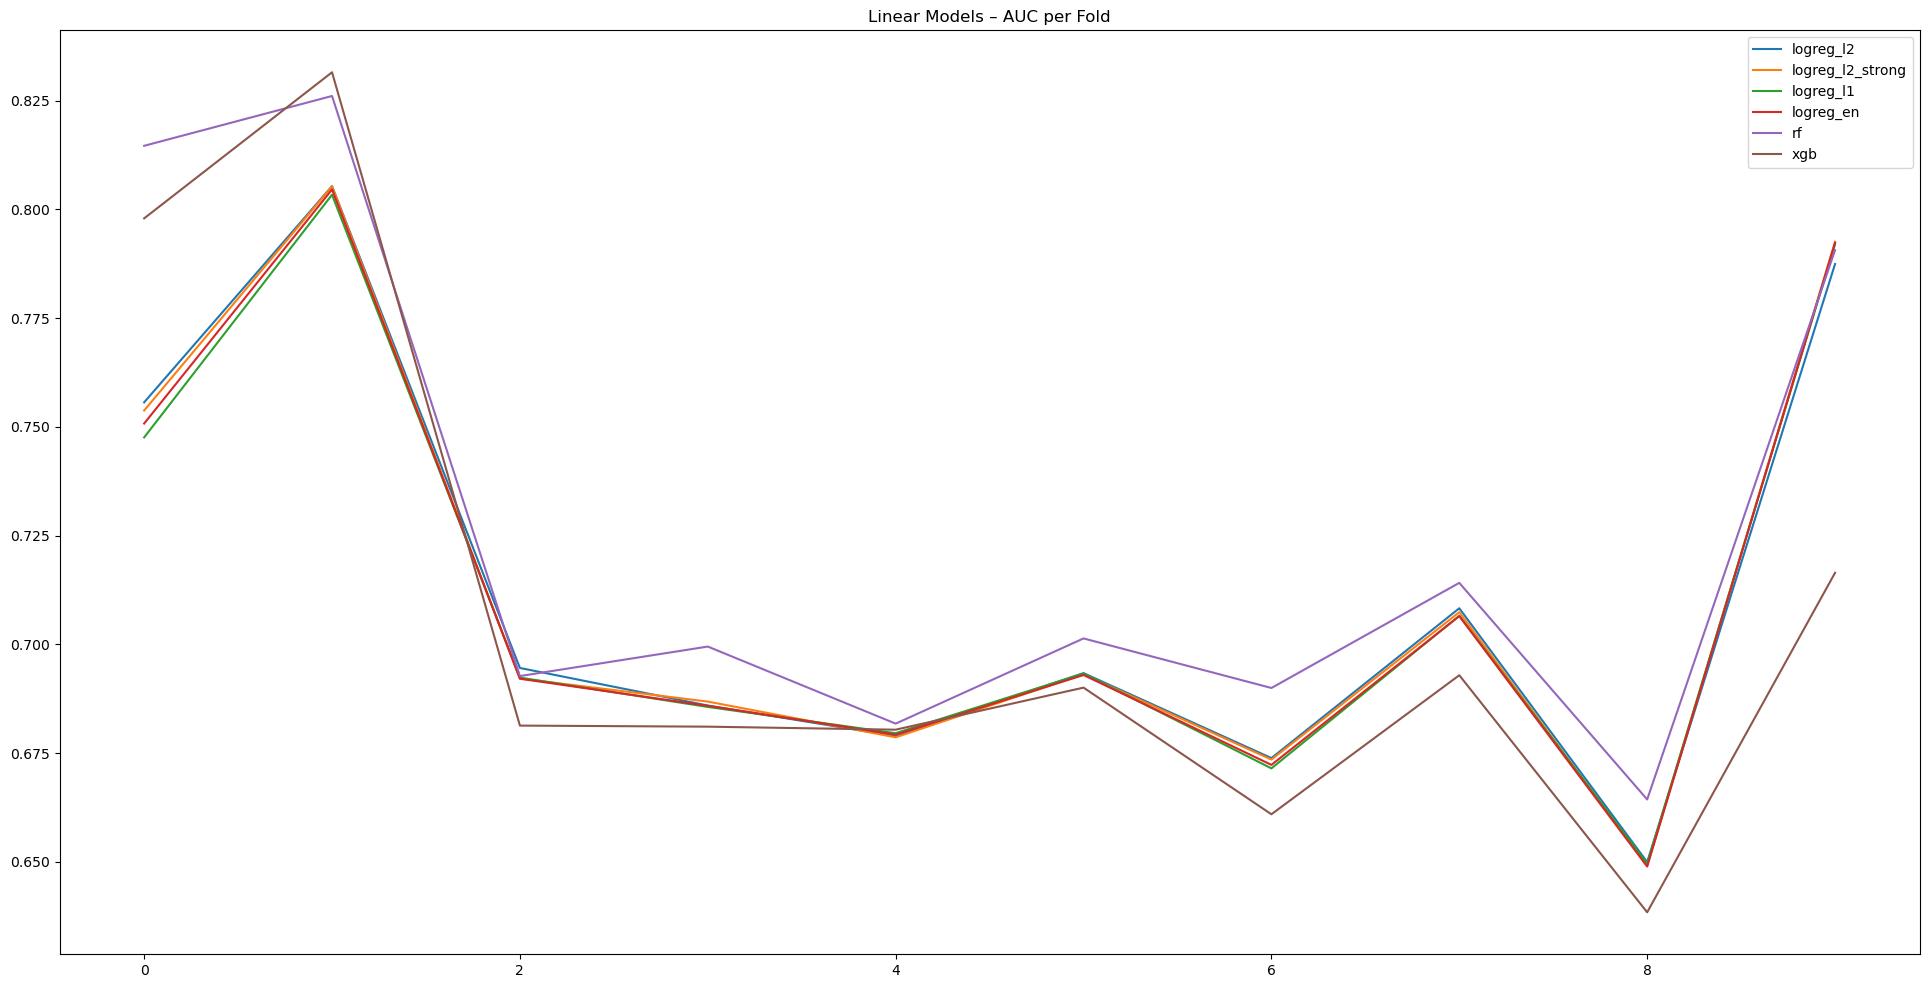

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 12))

for k, v in all_results.items():
    plt.plot(v["fold_aucs"], label=k)

plt.legend()
plt.title("Linear Models – AUC per Fold")
plt.show()

In [20]:
import pandas as pd

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(20))

max_bid_ask_vol_ratio_log1p    0.130671
trade_count_log1p              0.112722
imbalance_5                    0.078803
imbalance_10                   0.060742
total_bid_volume_10_log1p      0.055535
realized_vol_5_log1p           0.049749
lob_depth_ratio_4              0.049565
total_book_volume_log1p        0.049294
realized_vol_20_log1p          0.049243
trade_count_change             0.047317
avg_trade_size_log1p           0.046501
lob_depth_ratio_2              0.045895
rel_spread_log1p               0.045295
std_trade_size_log1p           0.045138
sell_volume_log1p              0.044951
max_trade_size_log1p           0.044461
imbalance_depth_3              0.044118
dtype: float32


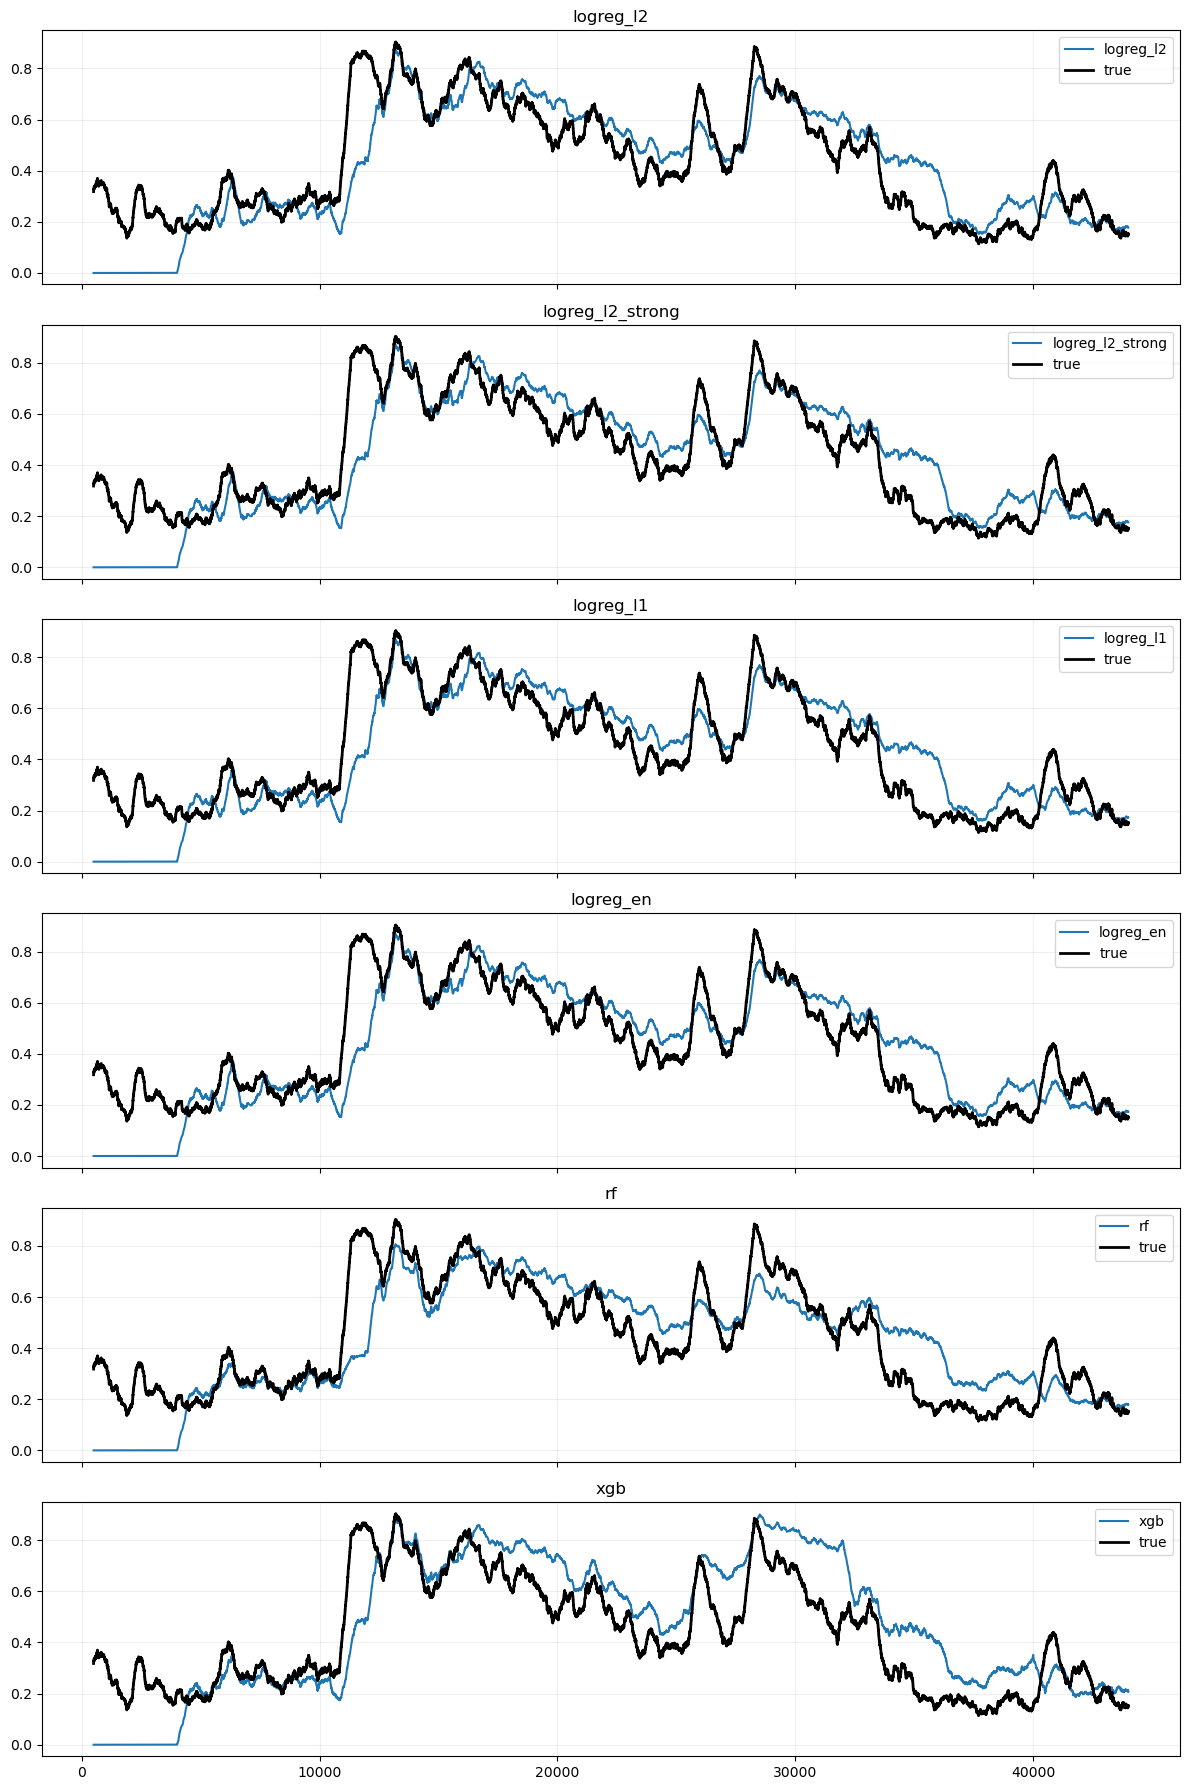

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

window = 500
y_true = y.values
target_smooth = pd.Series(y_true).rolling(window).mean()

n_models = len(all_results)
fig, axes = plt.subplots(n_models, 1, figsize=(12, 3 * n_models), sharex=True)

# if only 1 model, make axes iterable
if n_models == 1:
    axes = [axes]

for ax, (k, v) in zip(axes, all_results.items()):

    preds = np.nansum(v["fold_oof"], axis=0)

    pred_smooth = pd.Series(preds).rolling(window).mean()

    ax.plot(pred_smooth, label=k)
    ax.plot(target_smooth, color="black", linewidth=2, label="true")

    ax.set_title(k)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Model comparison via confidence thresholding

We evaluate models by trading only on high-confidence predictions.

For each model:
- Aggregate out-of-fold predictions into a single score
- Apply a quantile threshold (e.g. top 20%, 10%, 5%) to select trades
- Compute accuracy conditional on trading

This measures how well models perform when acting only on their strongest signals.

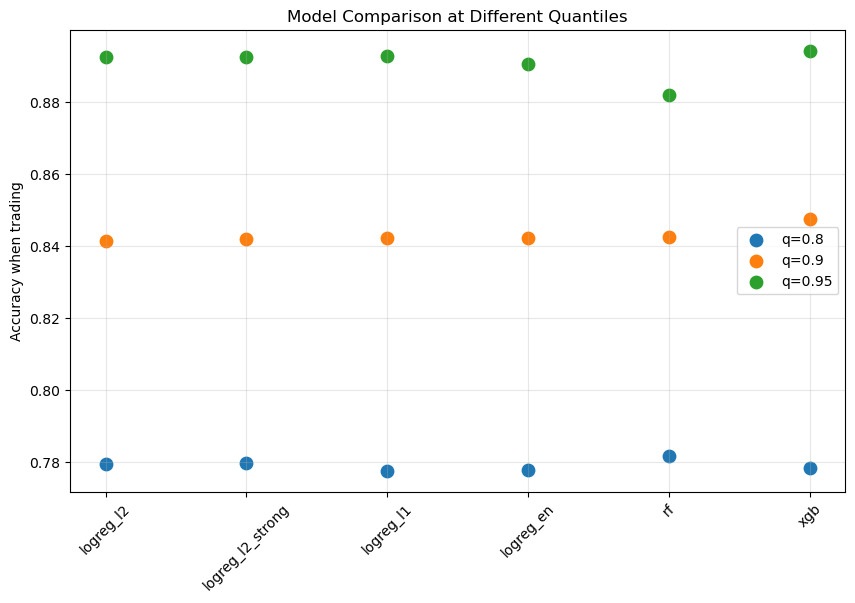

In [22]:
import matplotlib.pyplot as plt
import numpy as np

quantiles = [0.8, 0.9, 0.95]

model_names = list(all_results.keys())
x = np.arange(len(model_names))

plt.figure(figsize=(10, 6))

for q in quantiles:

    accs = []

    for name in model_names:

        preds = np.nansum(all_results[name]["fold_oof"], axis=0)

        threshold = np.quantile(preds, q)
        signal = preds > threshold

        acc = y_true[signal].mean()
        accs.append(acc)

    plt.scatter(x, accs, label=f"q={q}", s=80)

# formatting
plt.xticks(x, model_names, rotation=45)
plt.ylabel("Accuracy when trading")
plt.title("Model Comparison at Different Quantiles")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Currently best model

In [23]:
xgb= XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss"
)
features = [
# Vol
"realized_vol_20_log1p",
"realized_vol_5_log1p",

# trade intensity
"trade_count_log1p",
"trade_count_change",

# trade size
"std_trade_size_log1p",
"max_trade_size_log1p",
"avg_trade_size_log1p",

# liquidity
"total_bid_volume_10_log1p",
"total_book_volume_log1p",

# volume_pressure
"max_bid_ask_vol_ratio_log1p",

# spread
"rel_spread_log1p",

# imbalance
"imbalance_5",
"imbalance_10",
"imbalance_depth_3",

# depth shape
"lob_depth_ratio_4",
"lob_depth_ratio_2",

# trade_flow
"sell_volume_log1p",
]
target = "mid_price_moves"